C:\Users\JCMiller\AppData\Local\Temp\ipykernel_24144\902445419.py:76: UserWarning: Ignoring specified arguments in this call because figure with num: 0 already exists
  plt.figure(0, figsize= (4,3))
C:\Users\JCMiller\AppData\Local\Temp\ipykernel_24144\902445419.py:90: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize= (4,3))


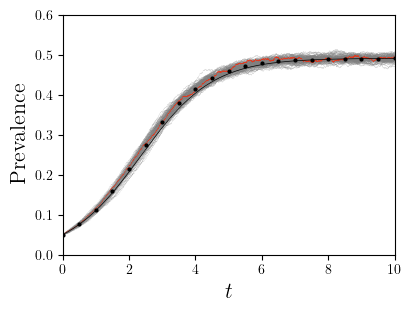

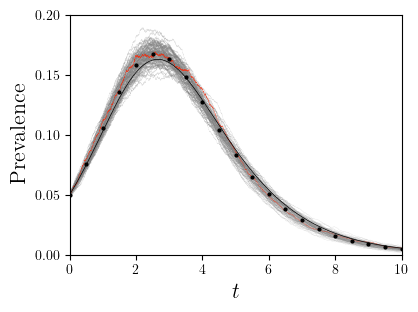

In [1]:
import EoN
import networkx as nx
from matplotlib import rc
import matplotlib.pyplot as plt
import numpy as np


#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)


colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'
colorI2 = '#0073B3'

rng = np.random.default_rng(1)
#handling random seeds as described in
#https://networkx.org/documentation/stable/reference/randomness.html
import random
random.seed(5)        # or any integer
np.random.seed(10)


N = 10000
kave = 30.
gamma = 1.
tau = 1./15
tmax = 10

rho = 0.05
iterations = 100

tcount = 21

report_times = np.linspace(0,tmax,tcount)

SIS_Isum=np.zeros(tcount)
SIR_Isum=np.zeros(tcount)
plt.figure(0, figsize= (4,3))
plt.figure(1, figsize= (4,3))
for counter in range(iterations):
    #do SIS simulation and then SIR simulation.
    G = nx.fast_gnp_random_graph(N, kave/(N-1))
    initial_infecteds = rng.choice(list(G.nodes()), int(rho*G.order()),replace=False)

    t, S, I = EoN.fast_SIS(G, tau, gamma, initial_infecteds=initial_infecteds, tmax=tmax)
    Isub = EoN.subsample(report_times, t, I)
    SIS_Isum += Isub
    plt.figure(0)
    if iterations-counter>1:
        plt.plot(t, I*1./N, linewidth=0.2, alpha=0.25, color='grey')
    else:   
        plt.plot(t, I*1./N, linewidth=0.2, alpha=0.75, color=colorI)
    

    t, S, I, R = EoN.fast_SIR(G, tau, gamma, initial_infecteds=initial_infecteds, tmax=tmax)
    
    Isub = EoN.subsample(report_times, t, I)
    SIR_Isum += Isub
    plt.figure(1)
    if iterations-counter>1:
        plt.plot(t, I*1./N, linewidth=0.2, alpha=0.25, color='grey')
    else:
        plt.plot(t, I*1./N, linewidth=0.2, alpha=0.75, color=colorI)
    

S0 = (1-rho)*N
I0 = rho*N
SI0 = (1-rho)*N*kave*rho
SS0 = (1-rho)*N*kave*(1-rho)
t, S, I = EoN.SIS_homogeneous_pairwise(S0, I0, SI0, SS0, kave, tau,
                                        gamma, tmax=tmax)
plt.figure(0, figsize= (4,3))
plt.plot(report_times,SIS_Isum/(N*iterations), 'o', color='k', markersize = 2, linewidth=0.5)
plt.plot(t, I/N, '-', color='k', linewidth=0.5)
plt.ylim([0,0.6])
plt.xlim([0,10])
plt.xlabel('$t$', fontsize=16)
plt.ylabel('Prevalence', fontsize=16)
plt.subplots_adjust(left=0.15, right=0.98, top=0.95, bottom=0.15)
plt.savefig('fig4p1c.png', dpi=900)


t, S, I, R = EoN.SIR_homogeneous_pairwise(S0, I0, 0, SI0, SS0, kave, tau,
                                        gamma, tmax=tmax)

plt.figure(1, figsize= (4,3))
plt.plot(report_times,SIR_Isum/(N*iterations), 'o', color='k', markersize = 2, linewidth=0.5)
plt.plot(t, I/N, '-', color='k', linewidth=0.5)
plt.xlabel('$t$', fontsize=16)
plt.ylabel('Prevalence', fontsize=16)
plt.ylim([0,0.2])
plt.xlim([0,10])
plt.yticks([0, 0.05, 0.1, 0.15, 0.2])
plt.subplots_adjust(left=0.15, right=0.98, top=0.95, bottom=0.15)
plt.savefig('fig4p1d.png', dpi=900)

# Figure 4.7


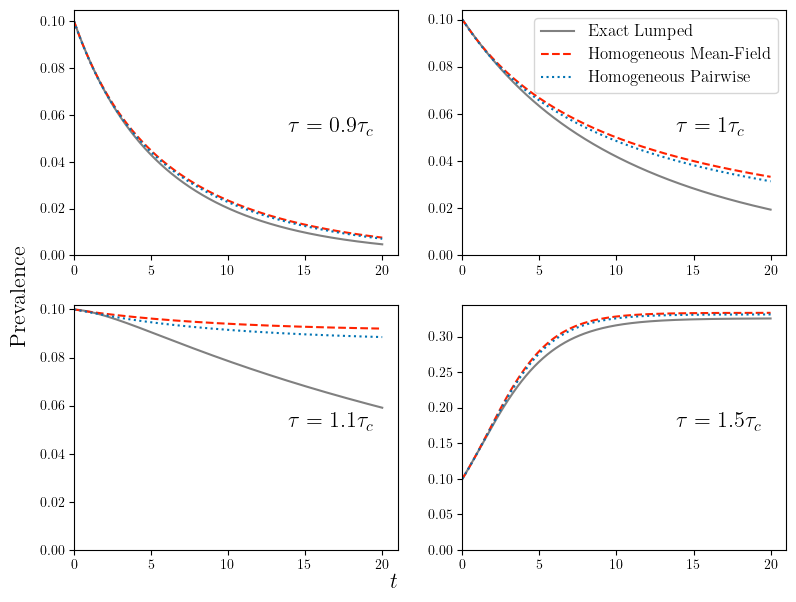

In [2]:
import EoN
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from scipy import integrate
from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'
colorI2 = '#0073B3'

def complete_graph_dX(X, t, tau, gamma, N):
    r'''This system is given in Proposition 2.3, taking Q=S, T=I
    f_{SI}(k) = f_{QT}= k*\tau
    f_{IS}(k) = f_{TQ} = \gamma

    \dot{Y}^0 = \gamma Y^1 - 0\\
    \dot{Y}^1 = 2\gamma Y^2  + 0Y^0 - (\gamma + (N-1)\tau)Y^1
    \dot{Y}^2 = 3\gamma Y^3 + (N-1)\tau Y^1 - (2\gamma+2(N-2))Y^2
    ...
    \dot{Y}^N = (N-1)\tau Y^{N-1} - N\gamma Y^N
    Note that X has length N+1
    '''
    #X[k] is probability of k infections.
    dX = []
    dX.append(gamma*X[1])
    for k in range(1,N):
        dX.append((k+1)*gamma*X[k+1]+ (N-k+1)*(k-1)*tau*X[k-1]
                    - ((N-k)*k*tau + k*gamma)*X[k])
    dX.append((N-1)*tau*X[N-1] - N*gamma*X[N])

    return np.array(dX)

def complete_graph_lumped(N, I0, tmin, tmax, tcount):
    times = np.linspace(tmin, tmax, tcount)
    X0 = np.zeros(N+1)  #length N+1 of just 0 entries
    X0[I0]=1. #start with 100 infected.
    X = integrate.odeint(complete_graph_dX, X0, times, args = (tau, gamma, N))
    #X[t] is array whose kth entry is p(k infected| time=t).
    I = np.array([sum(k*Pkt[k] for k in range(len(Pkt))) for Pkt in X])
    S = N-I
    return times, S, I



N=200
gamma = 1


k = N-1.
tau_c = gamma/k
rho = 0.1
fig, axes = plt.subplots(2,2,figsize=(8,6))
axes=axes.flatten()
for tau_factor, label, ax in zip([0.9, 1, 1.1, 1.5],['a', colorI2, 'c', 'd'], axes):
    tau = tau_factor*tau_c
    
    t, S, I = complete_graph_lumped(N, int(N*rho), 0 , 20, 1001)
    ax.plot(t, I/N, label = 'Exact Lumped', color = 'grey')

    S0 = (1-rho)*N
    I0 = rho*N

    t, S, I = EoN.SIS_homogeneous_meanfield(S0, I0, k, tau, gamma, tmin=0, tmax=20,
                                tcount=1001)
    ax.plot(t, I/N, '--', label = 'Homogeneous Mean-Field', color = colorI)
    S0 = (1-rho)*N
    I0 = rho*N
    SI0 = (1-rho)*N*k*rho
    SS0 = (1-rho)*N*k*(1-rho)
    t, S, I = EoN.SIS_homogeneous_pairwise(S0, I0, SI0, SS0, k, tau, gamma, tmin = 0,
                                tmax=20, tcount=1001)
    ax.plot(t, I/N, ':', label = 'Homogeneous Pairwise', color = colorI2)
    ax.set_ylim(ymin=0)
    ax.set_xlim(xmin=0)
    ax.text(0.66, 0.5, '$\\tau = {}\\tau_c$'.format(tau_factor), transform=ax.transAxes, fontsize=16)
#axes[0].set_ylabel('Prevalence', fontsize=10)
#axes[2].set_ylabel('Prevalence', fontsize=10)   
#axes[2].set_xlabel('$t$', fontsize=10)
#axes[3].set_xlabel('$t$', fontsize=10)
axes[1].legend(fontsize=12)
fig.supylabel('Prevalence', fontsize=16)
fig.supxlabel('$t$', fontsize=16)
plt.subplots_adjust(left=0.1, right=0.99, top=0.98, bottom=0.08)
plt.savefig('fig4p7.png', dpi=900)

# Figure 4.9


warning --- plot c in book is mislabeled.  It should be \tau = 1.1\tau_c, not 1.2\tau_c


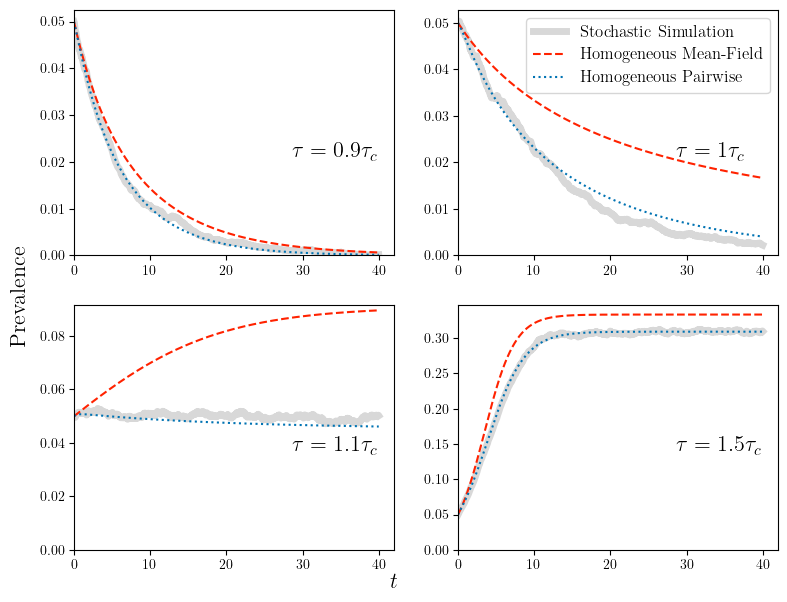

In [ ]:
import EoN
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)


colorS = '#009a80'
colorE = '#f0e442'
colorI = '#ff2200'
colorR = '#cd0ab3'
colorI2 = '#0073B3'

print(r"warning --- plot c in first edition is mislabeled.  It should be \tau = 1.1\tau_c, not 1.2\tau_c")
N=100000
kave = 20
gamma = 1.
iterations = 1
tmax = 40
tau_c = gamma/kave
rho = 0.05
tcount=1001

report_times = np.linspace(0,tmax,tcount)

fig, axes = plt.subplots(2,2,figsize=(8,6))
axes=axes.flatten()
plt.subplots_adjust(left=0.1, right=0.98, top=0.98, bottom=0.08)
for tau_factor, label, ax in zip([0.9, 1, 1.1, 1.5],['a', colorI2, 'c', 'd'], axes):
    tau = tau_factor*tau_c
    Isum = np.zeros(len(report_times))
    for counter in range(iterations):
        G = nx.configuration_model([kave]*N)
        t, S, I = EoN.fast_SIS(G, tau, gamma, tmax=tmax, rho=rho)
        I=I*1./N
        I = EoN.subsample(report_times, t, I)
        Isum += I
    ax.plot(report_times, Isum/iterations, label = 'Stochastic Simulation', color='grey', linewidth=5, alpha=0.3)


    S0 = (1-rho)*N
    I0 = rho*N

    t, S, I = EoN.SIS_homogeneous_meanfield(S0, I0, kave, tau, gamma, tmin=0, tmax=tmax,
                                tcount=tcount)
    ax.plot(t, I/N, '--', label = 'Homogeneous Mean-Field', color = colorI)
    S0 = (1-rho)*N
    I0 = rho*N
    SI0 = (1-rho)*N*kave*rho
    SS0 = (1-rho)*N*kave*(1-rho)
    t, S, I = EoN.SIS_homogeneous_pairwise(S0, I0, SI0, SS0, kave, tau, gamma, tmin = 0,
                                tmax=tmax, tcount=tcount)
    ax.plot(t, I/N, ':', label = 'Homogeneous Pairwise', color = colorI2)
    ax.set_ylim(ymin=0)
    ax.set_xlim(xmin=0)
    ax.text(0.68, 0.4, '$\\tau = {}\\tau_c$'.format(tau_factor), transform=ax.transAxes, fontsize=16)

axes[1].legend(fontsize=12)
fig.supylabel('Prevalence', fontsize=16)
fig.supxlabel('$t$', fontsize=16)
plt.savefig('fig4p9.png', dpi=900)

# Figure 4.10

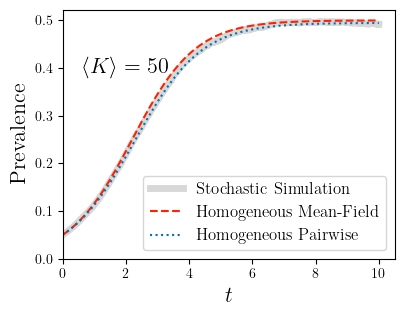

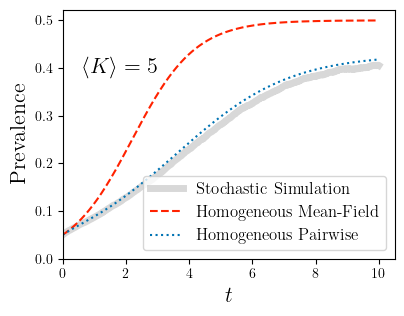

In [4]:
import EoN
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)


N=100000
gamma = 1.
iterations = 1
rho = 0.05
tmax = 10
tcount = 1001

report_times = np.linspace(0,tmax,tcount)

#plt.plot([],[])
#ax1 = plt.gca()#axes([0.1,0.1,0.9,0.9])
#ax2 = plt.axes([0.44,0.2,0.4,0.4])
plt.figure(0, figsize= (4,3))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
plt.figure(1, figsize= (4,3))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)

for kave, fig_id in zip([50, 5], [0,1]):
    fig=plt.figure(fig_id)
    tau = 2*gamma/kave
    Isum = np.zeros(tcount)

    for counter in range(iterations):
        G = nx.configuration_model(N*[kave])
        t, S, I = EoN.fast_SIS(G, tau, gamma, tmax=tmax, rho=rho)
        I = I*1./N
        I = EoN.subsample(report_times, t, I)
        Isum += I
    plt.plot(report_times, Isum/iterations, label = 'Stochastic Simulation', color='grey', linewidth=5, alpha=0.3)

    S0 = (1-rho)*N
    I0 = rho*N

    t, S, I = EoN.SIS_homogeneous_meanfield(S0, I0, kave, tau, gamma, tmin=0, tmax=tmax,
                                tcount=tcount)
    plt.plot(t, I/N, '--', label = 'Homogeneous Mean-Field', color = colorI)
    S0 = (1-rho)*N
    I0 = rho*N
    SI0 = (1-rho)*N*kave*rho
    SS0 = (1-rho)*N*kave*(1-rho)
    t, S, I = EoN.SIS_homogeneous_pairwise(S0, I0, SI0, SS0, kave, tau, gamma, tmin = 0,
                                tmax=tmax, tcount=tcount)
    plt.plot(t, I/N, ':', label = 'Homogeneous Pairwise', color = colorI2)

    plt.xlabel('$t$', fontsize=16)
    plt.ylabel('Prevalence', fontsize=16)
    plt.ylim(ymin=0)
    plt.xlim(xmin=0)
    plt.text(0.2, 0.77, '$\\langle K \\rangle = {}$'.format(kave), transform=fig.transFigure, fontsize=16)
plt.figure(0)
plt.legend(fontsize=12)
plt.savefig('fig4p10a.png', dpi = 900)
plt.figure(1)
plt.legend(fontsize=12)
plt.savefig('fig4p10b.png', dpi = 900)


# Fig 4.11

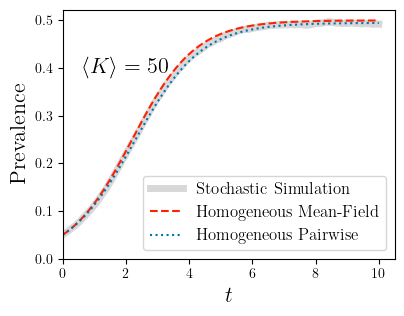

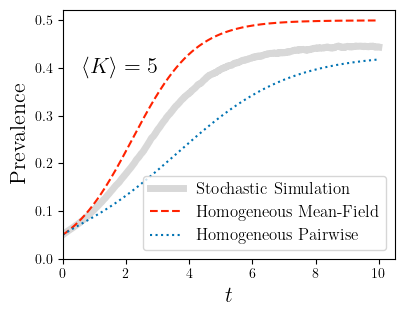

In [5]:
import EoN
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)


N=100000
gamma = 1.
iterations = 1
rho = 0.05
tmax = 10
tcount = 1001

report_times = np.linspace(0,tmax,tcount)

plt.figure(0, figsize= (4,3))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
plt.figure(1, figsize= (4,3))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)

for kave, fig_id in zip([50, 5], [0, 1]):
    
    fig=plt.figure(fig_id)
    tau = 2*gamma/kave
    Isum = np.zeros(tcount)

    for counter in range(iterations):
        G = nx.fast_gnp_random_graph(N, kave/(N-1.))
        t, S, I = EoN.fast_SIS(G, tau, gamma, tmax=tmax, rho=rho)
        I = I*1./N
        I = EoN.subsample(report_times, t, I)
        Isum += I
    plt.plot(report_times, Isum/iterations, label = 'Stochastic Simulation', color='grey', linewidth=5, alpha=0.3)

    S0 = (1-rho)*N
    I0 = rho*N

    t, S, I = EoN.SIS_homogeneous_meanfield(S0, I0, kave, tau, gamma, tmin=0, tmax=tmax,
                                tcount=tcount)
    plt.plot(t, I/N, '--', label = 'Homogeneous Mean-Field', color = colorI)
    S0 = (1-rho)*N
    I0 = rho*N
    SI0 = (1-rho)*N*kave*rho
    SS0 = (1-rho)*N*kave*(1-rho)
    t, S, I = EoN.SIS_homogeneous_pairwise(S0, I0, SI0, SS0, kave, tau, gamma, tmin = 0,
                                tmax=tmax, tcount=tcount)
    plt.plot(t, I/N, ':', label = 'Homogeneous Pairwise', color = colorI2)
    plt.ylim(ymin=0)
    plt.xlim(xmin=0)
    plt.xlabel('$t$', fontsize=16)
    plt.ylabel('Prevalence', fontsize=16)
    plt.text(0.2, 0.77, '$\\langle K \\rangle = {}$'.format(kave), transform=fig.transFigure, fontsize=16)
plt.figure(0)
plt.legend(fontsize=12)
plt.savefig('fig4p11a.png', dpi=900)
plt.figure(1)
plt.legend(fontsize=12)
plt.savefig('fig4p11b.png', dpi=900)


# Fig 4.12

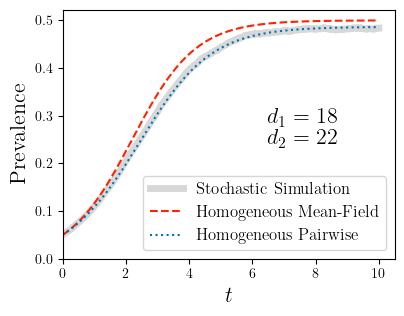

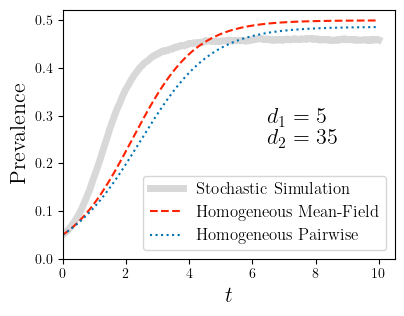

In [6]:
import EoN
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)


N=100000
gamma = 1.
iterations = 1
rho = 0.05
tmax = 10
tcount = 1001

report_times = np.linspace(0,tmax,tcount)

deg_dist1 = [18,22]*int((N/2)+0.01)
deg_dist2 = [5,35]*int((N/2)+0.01)

plt.figure(0, figsize= (4,3))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
plt.figure(1, figsize= (4,3))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)

for deg_dist, fig_id in zip([deg_dist1, deg_dist2], [0, 1]):
    fig=plt.figure(fig_id)
    
    kave = sum(deg_dist1)*1./N
    tau = 2*gamma/kave
    Isum = np.zeros(tcount)

    for counter in range(iterations):
        G = nx.configuration_model(deg_dist)
        t, S, I = EoN.fast_SIS(G, tau, gamma, tmax=tmax, rho=rho)
        I = I*1./N
        I = EoN.subsample(report_times, t, I)
        Isum += I
    plt.plot(report_times, Isum/iterations, label = 'Stochastic Simulation', color='grey', linewidth=5, alpha=0.3)

    S0 = (1-rho)*N
    I0 = rho*N

    t, S, I = EoN.SIS_homogeneous_meanfield(S0, I0, kave, tau, gamma, tmin=0, tmax=tmax,
                                tcount=tcount)
    plt.plot(t, I/N, '--', label = 'Homogeneous Mean-Field', color = colorI)

    SI0 = (1-rho)*N*kave*rho
    SS0 = (1-rho)*N*kave*(1-rho)
    t, S, I = EoN.SIS_homogeneous_pairwise(S0, I0, SI0, SS0, kave, tau, gamma, tmin = 0,
                                tmax=tmax, tcount=tcount)
    plt.plot(t, I/N, ':', label = 'Homogeneous Pairwise', color = colorI2)
    plt.xlabel('$t$', fontsize=16)
    plt.ylabel('Prevalence', fontsize=16)
    plt.ylim(ymin=0)
    plt.xlim(xmin=0)
    plt.text(0.66, 0.6, '$d_1 = {}$'.format(deg_dist[0]), transform=fig.transFigure, fontsize=16)
    plt.text(0.66, 0.53, '$d_2 = {}$'.format(deg_dist[1]), transform=fig.transFigure, fontsize=16)
plt.figure(0)
plt.legend(fontsize=12)
plt.savefig('fig4p12a.png', dpi=900)
plt.figure(1)
plt.legend(fontsize=12)
plt.savefig('fig4p12b.png', dpi=900)




# Fig 4.13


Warning, first edition says \tau=2\gamma/<K>, but it's really 1.5\gamma/<K>.  I tried 2, but it looks bad
Warning - for the power law graph the text says k_{max}=110, but I believe it is 118.


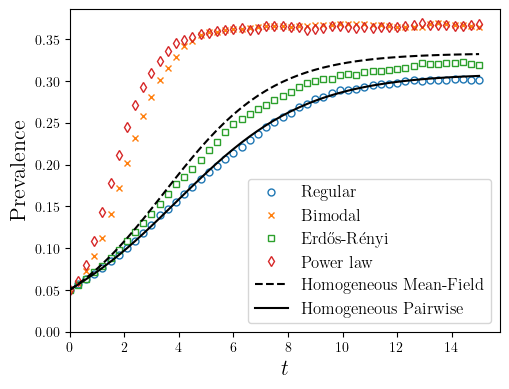

In [7]:
import EoN
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

print(r"Warning, first edition says \tau=2\gamma/<K>, but it's really 1.5\gamma/<K>.  I tried 2, but it looks bad")
print(r"Warning - for the power law graph the text says k_{max}=110, but I believe it is 118.")

N=100000
gamma = 1.
iterations = 1
rho = 0.05
tmax = 15
tcount = 51

kave = 20


tau = 1.5*gamma/kave

plt.figure(0, figsize= (5,3.75))
plt.subplots_adjust(left=0.12, right=0.98, top=0.98, bottom=0.12)


def simulate_process(graph_function, iterations, tmax, tcount, rho, kave, tau, gamma, symbol, label):
    Isum = np.zeros(tcount)
    report_times = np.linspace(0,tmax,tcount)
    for counter in range(iterations):
        G = graph_function()
        t, S, I = EoN.fast_SIS(G, tau, gamma, rho=rho, tmax=tmax)
        I = EoN.subsample(report_times, t, I)
        Isum += I
    plt.plot(report_times, Isum*1./(N*iterations), symbol, markersize = 5, markerfacecolor = 'none', label = label)

#regular
symbol = 'o'
graph_function = lambda : nx.configuration_model(N*[kave])
simulate_process(graph_function, iterations, tmax, tcount, rho, kave, tau, gamma, symbol, 'Regular')

#bimodal
symbol='x'
graph_function = lambda: nx.configuration_model([5,35]*int(N/2+0.01))
simulate_process(graph_function, iterations, tmax, tcount, rho, kave, tau, gamma, symbol, 'Bimodal')

#erdos-renyi
symbol = 's'
graph_function = lambda : nx.fast_gnp_random_graph(N, kave/(N-1.))
simulate_process(graph_function, iterations, tmax, tcount, rho, kave, tau, gamma, symbol, "Erd\\H{o}s-R\\'{e}nyi")

symbol = 'd'
pl_kmax = 118
pl_kmin = 7
pl_alpha = 2.
Pk={}
for k in range(pl_kmin, pl_kmax+1):
    Pk[k] = k**(-pl_alpha)
valsum = sum(Pk.values())
for k in Pk.keys():
    Pk[k] /= valsum

#print sum(k*Pk[k] for k in Pk.keys())
def generate_sequence(Pk, N):
    while True:
        sequence = []
        for counter in range(N):
            r = random.random()
            for k in Pk.keys():
                if r< Pk[k]:
                    break
                else:
                    r-=Pk[k]
            sequence.append(k)
        if sum(sequence)%2==0:
            break
    return sequence

graph_function = lambda : nx.configuration_model(generate_sequence(Pk,N))
simulate_process(graph_function, iterations, tmax, tcount, rho, kave, tau, gamma, symbol, 'Power law')

symbol = '--'
S0 = (1-rho)*N
I0 = rho*N
t, S, I = EoN.SIS_homogeneous_meanfield(S0, I0, kave, tau, gamma, tmax=tmax, tcount=tcount)
plt.plot(t, I/N, symbol, color='k', label = 'Homogeneous Mean-Field')

symbol = '-'
S0 = (1-rho)*N
I0 = rho*N
SI0 = (1-rho)*N*kave*rho
SS0 = (1-rho)*N*kave*(1-rho)
t, S, I = EoN.SIS_homogeneous_pairwise(S0, I0, SI0, SS0, kave, tau, gamma, tmax=tmax, tcount=tcount)
plt.plot(t, I/N, symbol, color='k', label = 'Homogeneous Pairwise')
plt.xlim(xmin=0)
plt.ylim(ymin=0)
plt.legend(fontsize=12)
plt.xlabel('$t$', fontsize=16)
plt.ylabel('Prevalence', fontsize=16)
plt.savefig('fig4p13.png', dpi = 900)

# Fig 4.14

Often stochastic effects cause the peak for <K>=50 to be lower than predicted.
See comments in code for explanation


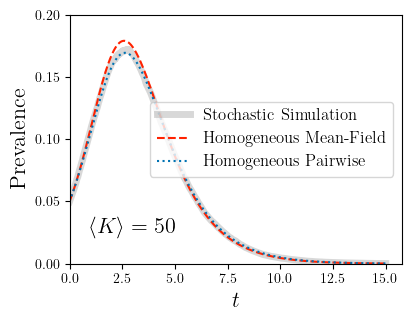

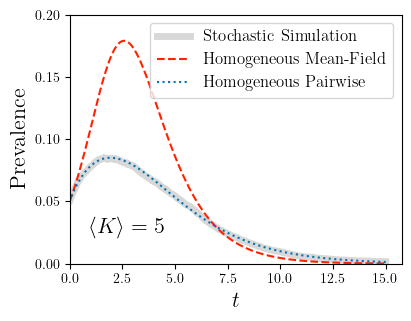

In [8]:
import EoN
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

r'''
Reproduces figure 4.12

With N=1000, there is still significant stochasticity.  Some epidemics have earlier
peaks than others.  When many of these are averaged together, the final outcome
is that the average has a lower, broader peak than a typical epidemic.

Increasing N to 10000 will eliminate this.
'''

print("Often stochastic effects cause the peak for <K>=50 to be lower than predicted.")
print("See comments in code for explanation")


N=100000
gamma = 1.
iterations = 1
rho = 0.05
tmax = 15
tcount = 1001

report_times = np.linspace(0,tmax,tcount)

plt.figure(0, figsize= (4,3))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
plt.figure(1, figsize= (4,3))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
#ax1 = plt.gca()#axes([0.1,0.1,0.9,0.9])
#ax2 = plt.axes([0.44,0.45,0.4,0.4])

for kave, fig_id in zip((50, 5), [0, 1]):
    fig=plt.figure(fig_id)
    tau = 2*gamma/kave
    Isum = np.zeros(tcount)

    for counter in range(iterations):
        G = nx.configuration_model(N*[kave])
        t, S, I, R = EoN.fast_SIR(G, tau, gamma, tmax=tmax, rho=rho)
        I = I*1./N
        I = EoN.subsample(report_times, t, I)
        Isum += I
    plt.plot(report_times, Isum/iterations, label = 'Stochastic Simulation', color='grey', linewidth=5, alpha=0.3)

    S0 = (1-rho)*N
    I0 = rho*N
    R0=0

    t, S, I, R = EoN.SIR_homogeneous_meanfield(S0, I0, R0, kave, tau, gamma,
                                            tmax=tmax, tcount=tcount)
    plt.plot(t, I/N, '--', label = 'Homogeneous Mean-Field', color = colorI)

    SI0 = (1-rho)*N*kave*rho
    SS0 = (1-rho)*N*kave*(1-rho)
    t, S, I, R = EoN.SIR_homogeneous_pairwise(S0, I0, R0, SI0, SS0, kave, tau, gamma,
                                tmax=tmax, tcount=tcount)
    plt.plot(t, I/N, label = 'Homogeneous Pairwise', linestyle=':', color = colorI2)
    plt.xlabel('$t$', fontsize=16)
    plt.ylabel('Prevalence', fontsize=16)
    plt.xlim(xmin=0)
    plt.ylim(ymin=0)
    plt.yticks([0, 0.05, 0.1, 0.15, 0.2])
    plt.text(0.2, 0.25, '$\\langle K \\rangle = {}$'.format(kave), transform=fig.transFigure, fontsize=16)
    


plt.figure(0)
plt.legend(loc = 'center right', fontsize=12)
plt.savefig('fig4p14a.png', dpi = 900)
plt.figure(1)
plt.legend(loc = 'upper right', fontsize=12)
plt.savefig('fig4p14b.png', dpi=900)

# Fig 4.15

Often stochastic effects cause the peak for <K>=50 to be lower than predicted.
See comments in code for explanation


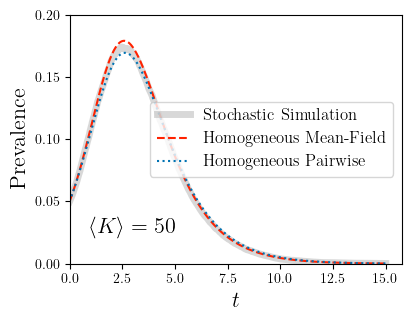

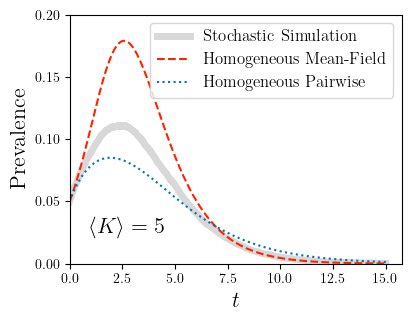

In [9]:
import EoN
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

#commands to make legend be in LaTeX font
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

r'''
Reproduces figure 4.13

With N=1000, there is still significant stochasticity.  Some epidemics have earlier
peaks than others.  When many of these are averaged together, the final outcome
is that the average has a lower, broader peak than a typical epidemic.  In
this case it tends to make the Erdos-Renyi network for <K>=50 look like a better
fit for the homogeneous_pairwise model.

Increasing N to 10000 will eliminate this.
'''

print("Often stochastic effects cause the peak for <K>=50 to be lower than predicted.")
print("See comments in code for explanation")



N=100000
gamma = 1.
iterations = 1
rho = 0.05
tmax = 15
tcount = 1001

report_times = np.linspace(0,tmax,tcount)

plt.figure(0, figsize= (4,3))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
plt.figure(1, figsize= (4,3))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)

for kave, fig_id in zip((50, 5), [0, 1]):
    fig=plt.figure(fig_id)
    tau = 2*gamma/kave
    Isum = np.zeros(tcount)

    for counter in range(iterations):
        G = nx.fast_gnp_random_graph(N,kave/(N-1.))
        t, S, I, R = EoN.fast_SIR(G, tau, gamma, tmax=tmax, rho=rho)
        I = I*1./N
        I = EoN.subsample(report_times, t, I)
        Isum += I
    plt.plot(report_times, Isum/iterations, label = 'Stochastic Simulation', color='grey', linewidth=5, alpha=0.3)

    S0 = (1-rho)*N
    I0 = rho*N
    R0=0

    t, S, I, R = EoN.SIR_homogeneous_meanfield(S0, I0, R0, kave, tau, gamma,
                                            tmax=tmax, tcount=tcount)
    plt.plot(t, I/N, '--', label = 'Homogeneous Mean-Field', color = colorI)

    SI0 = (1-rho)*N*kave*rho
    SS0 = (1-rho)*N*kave*(1-rho)
    t, S, I, R = EoN.SIR_homogeneous_pairwise(S0, I0, R0, SI0, SS0, kave, tau, gamma,
                                tmax=tmax, tcount=tcount)
    plt.plot(t, I/N, label = 'Homogeneous Pairwise', linestyle=':', color = colorI2)

    plt.xlim(xmin=0)
    plt.ylim(ymin=0)
    plt.xlabel('$t$', fontsize=16)
    plt.ylabel('Prevalence', fontsize=16)
    plt.yticks([0, 0.05, 0.1, 0.15, 0.2])
    plt.text(0.2, 0.25, '$\\langle K \\rangle = {}$'.format(kave), transform=fig.transFigure, fontsize=16)
    

plt.figure(0)
plt.legend(loc = 'center right', fontsize=12)
plt.savefig('fig4p15a.png', dpi=900)
plt.figure(1)
plt.legend(loc = 'upper right', fontsize=12)
plt.savefig('fig4p15b.png', dpi = 900)